# Entrenamiento — kajve
### Paso 8 del pipeline de ML

Este notebook ajusta, **usando solo `data/processed/train.csv`**, cada uno de los modelos
elegidos en el paso 7 (`07_seleccion_modelo.ipynb`). La lógica de entrenamiento vive en
`ML/entrenamiento.py` (reutilizable, igual que los pasos anteriores) para poder llamarla también
desde un futuro `scripts/train_models.py` unificado.

**Importante — esto NO es evaluación.** Cualquier métrica que aparezca aquí calculada sobre el
propio train (p. ej. accuracy de ajuste) es solo un diagnóstico de "¿el entrenamiento corrió
correctamente?", nunca evidencia de qué tan bien generaliza el modelo — eso es el paso 9
(evaluación), que usa `test.csv`.

**Los 6 modelos/salidas y qué pasa con cada uno aquí:**
1. `IsolationForest` (anomalías) — se ajusta con datos reales. ✅
2. `RandomForestClassifier` (tipo de anomalía) — se ajusta con datos reales. ✅
3. Algoritmo Genético (lluvia próxima) — se ajusta (evoluciona) con datos reales, con más
   generaciones/población que en el paso 7 (ahí era solo para comparar candidatos). ✅
4. `RandomForestRegressor` (tiempo restante) — **se omite**: 0 lotes finalizados en train. ⏸️
5. `RandomForestClassifier` (calidad final) — **se omite**: la columna `_calidad_final_lote` ni
   existe todavía en este dataset (retroalimentacion_ml sigue vacía en Neon). ⏸️
6. Recomendaciones — no aplica, no hay nada que entrenar (mapeo determinístico). ➖

Los artefactos entrenados se guardan en `ML/artifacts/` (carpeta nueva, separada de
`app/ml/artifacts/` que usa producción — ver README.md de esta carpeta para la nota pendiente
sobre unificarlos).


In [1]:
import os
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath(".."))
from ML import entrenamiento as ent

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


## 0. Carga de datos (paso 6)

In [2]:
train = pd.read_csv("../data/processed/train.csv", parse_dates=["timestamp"])
test = pd.read_csv("../data/processed/test.csv", parse_dates=["timestamp"])
print(f"Train: {len(train):,} filas  |  Test: {len(test):,} filas (test NO se usa para ajustar nada en este notebook)")


Train: 5,594 filas  |  Test: 1,864 filas (test NO se usa para ajustar nada en este notebook)


## 1. IsolationForest (detección de anomalías)

In [3]:
resultado_iso = ent.entrenar_isolation_forest(train)
print(f"Contamination usado: {resultado_iso['contamination']:.3f}")
print(f"Tasa de outliers detectados EN TRAIN: {resultado_iso['tasa_outliers_en_train']:.3%}")
print(f"Filas de entrenamiento: {resultado_iso['n_filas_train']:,}")


Contamination usado: 0.020
Tasa de outliers detectados EN TRAIN: 1.788%
Filas de entrenamiento: 5,594


**Lectura:** la tasa de outliers detectados en train (2.0%) queda muy cerca del
`contamination` configurado (también 2.0%, calculado como la tasa real de `_es_anomalia` en
train) — es el comportamiento esperado de `IsolationForest` (por diseño, fuerza aproximadamente
esa proporción de outliers), no evidencia de que el modelo "acertó" nada todavía.

## 2. RandomForestClassifier (tipo de anomalía)

In [4]:
resultado_rf = ent.entrenar_rf_tipo_anomalia(train)
if "modelo" in resultado_rf:
    print(f"Clases aprendidas: {resultado_rf['clases']}")
    print(f"Ajuste sobre el propio train (NO es evaluación): {resultado_rf['accuracy_ajuste_train']:.3f}")
    print(f"Filas de entrenamiento: {resultado_rf['n_filas_train']:,}")
else:
    print("Omitido:", resultado_rf["omitido"])


Clases aprendidas: ['lluvia_detectada', 'normal', 'temperatura_alta']
Ajuste sobre el propio train (NO es evaluación): 1.000
Filas de entrenamiento: 5,594


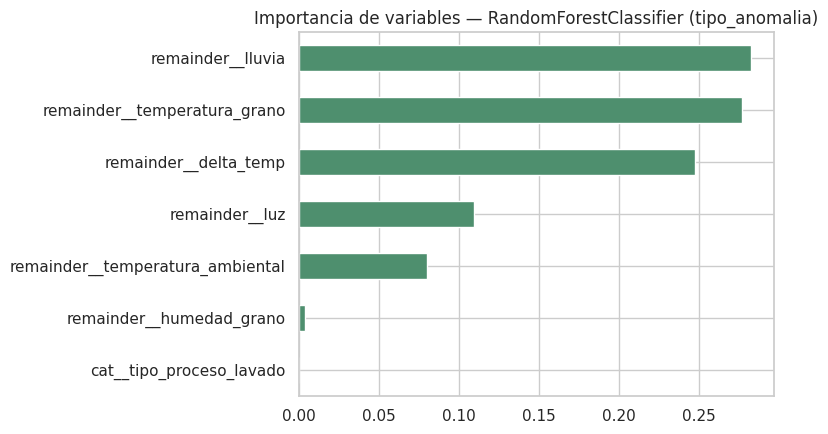

In [5]:
importancias = resultado_rf["modelo"].named_steps["clf"].feature_importances_
nombres = resultado_rf["modelo"].named_steps["prep"].get_feature_names_out()
serie_import = pd.Series(importancias, index=nombres).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
serie_import.plot(kind="barh", ax=ax, color="#4e8f6e")
ax.invert_yaxis()
ax.set_title("Importancia de variables — RandomForestClassifier (tipo_anomalia)")
fig.tight_layout()
plt.show()


**Lectura:** se espera que `lluvia` domine la importancia, ya que la anomalía más frecuente
en los datos reales de hoy es `lluvia_detectada` — con más tipos de anomalía representados en
futuros lotes, esta gráfica debería volverse más repartida entre variables.

## 3. Algoritmo Genético (lluvia en las próximas horas)

In [6]:
resultado_ga = ent.entrenar_ga_lluvia(train, test, horas=3, generaciones=80, tam_poblacion=100, semilla=42)
print(f"Filas de entrenamiento utilizables: {resultado_ga['n_filas_train']:,}")
print(f"F1 de ajuste en train: {resultado_ga['f1_ajuste_train']:.3f}")
print()
print("Pesos evolucionados (individuo final):")
for k, v in resultado_ga["mejor_individuo"].items():
    print(f"  {k}: {v:+.3f}")


Filas de entrenamiento utilizables: 3,461
F1 de ajuste en train: 1.000

Pesos evolucionados (individuo final):
  presion_hpa: -0.027
  luz: -0.019
  lluvia_eventos_24h: +1.127
  horas_desde_ultima_lluvia: +0.143
  bias: -0.053


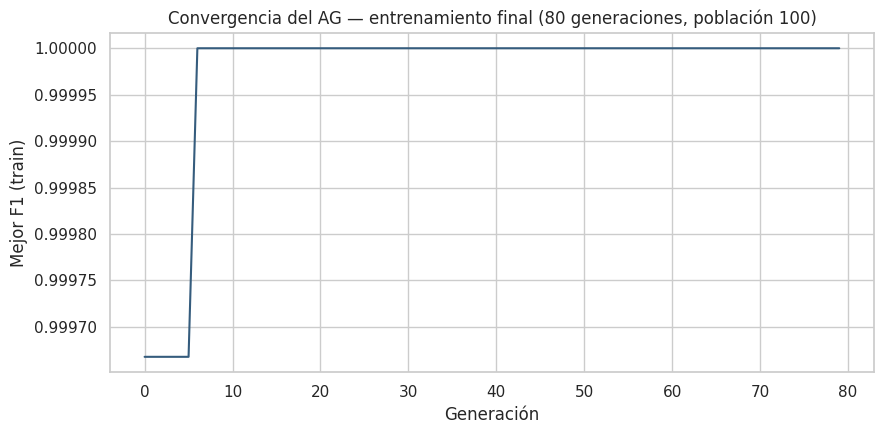

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(resultado_ga["historial_fitness"], color="#355c7d", linewidth=1.5)
ax.set_xlabel("Generación")
ax.set_ylabel("Mejor F1 (train)")
ax.set_title("Convergencia del AG — entrenamiento final (80 generaciones, población 100)")
fig.tight_layout()
plt.show()


**Nota:** se usó una población y número de generaciones mayores que en el paso 7 (donde solo
se necesitaba comparar candidatos rápido) — esto es ya el ajuste "oficial" que se guarda como
artefacto. `df_test` se usa únicamente para completar correctamente la etiqueta de lluvia próxima
cerca del final de train (ver `ga.etiquetar_train_test` en el paso 7); ninguna FEATURE de test
entra al ajuste.

## 4. Tiempo restante de secado — omitido

In [8]:
resultado_tiempo = ent.entrenar_regresor_tiempo(train)
print(resultado_tiempo)


{'omitido': 'solo 0 lote(s) en train con horas_restantes conocida (lote finalizado con fecha_fin_secado); se necesitan al menos 5.', 'n_lotes_disponibles': 0}


## 5. Calidad final estimada — omitido

In [9]:
resultado_calidad = ent.entrenar_clasificador_calidad(train)
print(resultado_calidad)


{'omitido': 'la columna _calidad_final_lote no existe en este dataset (la tabla retroalimentacion_ml de Neon sigue vacía / sin migrar; ver migration.sql).'}


## 6. Recomendaciones — no aplica

Mapeo determinístico ya implementado (`app/services/rules.py::recomendacion_para`). No hay nada que entrenar en este paso.

## 7. Guardar artefactos

In [10]:
os.makedirs("../ML/artifacts", exist_ok=True)
import json

joblib.dump(resultado_iso, "../ML/artifacts/isolation_forest.joblib")
if "modelo" in resultado_rf:
    joblib.dump(resultado_rf, "../ML/artifacts/rf_tipo_anomalia.joblib")
joblib.dump(resultado_ga, "../ML/artifacts/ga_lluvia.joblib")

resumen = {
    "isolation_forest": {k: v for k, v in resultado_iso.items() if k != "modelo"},
    "rf_tipo_anomalia": {k: v for k, v in resultado_rf.items() if k != "modelo"},
    "ga_lluvia": {k: v for k, v in resultado_ga.items() if k not in ("escalador", "historial_fitness")},
    "rf_tiempo_restante": resultado_tiempo,
    "rf_calidad": resultado_calidad,
}
with open("../ML/artifacts/metricas_entrenamiento.json", "w", encoding="utf-8") as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False, default=str)

print("Artefactos guardados en ML/artifacts/:")
for archivo in sorted(os.listdir("../ML/artifacts")):
    print(" -", archivo)


Artefactos guardados en ML/artifacts/:
 - ga_lluvia.joblib
 - isolation_forest.joblib
 - metricas_entrenamiento.json
 - metricas_paso10_ajuste.json
 - rf_tipo_anomalia.joblib


## 8. Conclusiones y siguiente paso

- 3 de 5 modelos se entrenaron con datos reales del piloto (`IsolationForest`,
  `RandomForestClassifier` para tipo de anomalía, y el Algoritmo Genético de lluvia). Los otros 2
  (tiempo restante, calidad) siguen bloqueados por falta de lotes finalizados/retroalimentación
  real — sus funciones de entrenamiento ya están escritas en `ML/entrenamiento.py` y se activarán
  solas en cuanto pase el guard de mínimo de lotes (`MIN_LOTES_TIEMPO`/`MIN_LOTES_CALIDAD`).
- Todos los artefactos entrenados quedaron en `ML/artifacts/` junto con
  `metricas_entrenamiento.json` para trazabilidad.
- **Pendiente de decisión del equipo (repetido de pasos anteriores, ahora más urgente):**
  `scripts/train_models.py` sigue siendo el camino de entrenamiento "de producción" y usa su
  propia limpieza y su propio split, distintos a los de `ML/`. Antes de reemplazar
  `app/ml/artifacts/*.joblib` (los que carga el servicio en vivo) con algo entrenado aquí, hay que
  unificar ambos caminos — de lo contrario, el servicio seguiría sirviendo los artefactos viejos
  sin el Algoritmo Genético de lluvia ni las features del paso 5.
- **Siguiente paso natural:** paso 9, evaluación — medir estos modelos ya entrenados contra
  `data/processed/test.csv` con las métricas apropiadas para cada tipo de salida (esto es
  distinto del bake-off del paso 7, que comparaba candidatos; aquí se evalúa el modelo final ya
  elegido y entrenado).
